# TM-RugPull dataset initial analysis

## Data collection

## Data collection

In [4]:
# Loading data from .xlsx file

import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot

file = 'data/TM-RugPull.xlsx'

data = pd.read_excel(file)

# Remove a space in the end of some column names
data.columns = data.columns.str.strip()

print(data.shape)

pd.set_option('display.max_columns', None)

data.head(5)

(1000, 27)


,Project Title,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,Sign,first deposits,Blockchain Type,Smart Contract (online),smart Contract (offline),website,x profile,class,project starting date,project end date,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
0,HyperVerse Token (HVT),7.650000e+00,1.500000e-01,9.100000e-06,8.000000e-07,BSC,623909,25752,9.537265e-03,4.929203e-02,166600000000100,HVT,44,POSA,sourse code,CODE,https://thehyperverse.net/index.html,https://twitter.com/HyperVerse6,scam,2022-01-27,2023-07-14,148,148,29,8,74,47
1,Fintoch,1.795000e-11,1.907000e-11,1.727000e-10,1.769000e-10,BSC,"1,492,842","147,791",2.487228e+03,4.503032e+07,34403.74594,BEP-20 TOKEN*,1,POSA,sourse code,CODE,https://web.archive.org/web/20230603123631/htt...,NaN,scam,2022-07-12,2023-06-19,820,167,4530,1590,48,4
2,Flare Token,1.955000e-03,5.519000e-04,4.158000e-04,2.838000e-04,BSC,"184,694",15173,8.901714e+14,6.695544e+17,10000000000,Flare,53,POSA,sourse code,CODE,https://pipeflare.io/,https://x.com/MetaFlareToken,scam,2021-10-24,2022-11-24,421,156,6,5,1710,1150
3,Safuu Protocol,2.070000e+02,2.110000e+02,7.000000e+01,2.400000e+01,BSC,"275,530",151979,2.457331e+10,8.139816e+14,61634066.59803,SAFUU,2,POSA,sourse code,CODE,https://safuu.com/,https://x.com/safuuxofficial,scam,2022-02-03,2022-08-13,327,323,0,0,5,4
4,SCT,2.986000e-01,1.659000e-01,1.831000e-01,1.552000e-01,BSC,8445,"6,126\n",4.252172e+06,1.410127e+05,"42,896,736.739367",SCT,52,POSA,sourse code,CODE,https://supercells.jp/en/,https://x.com/scttoken,scam,2023-02-27,2024-07-09,4990000,345000,6,3,1830,594


In [5]:
# Check the balance between classes in the whole dataset
# Source: https://note.nkmk.me/en/python-pandas-value-counts/#value_counts

class_counts = data['class'].value_counts()
class_percent = data['class'].value_counts(normalize=True) * 100

print("Counts:", class_counts.to_string(), "\nIn %:", class_percent.to_string())

Counts: class
scam      599
normal    401 
In %: class
scam      59.9
normal    40.1


##### Create a test set and a validation test

In [6]:
# Check general info about data

print("\nDataset information:")
data.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                                                 Non-Null Count  Dtype         
---  ------                                                 --------------  -----         
 0   Project Title                                          1000 non-null   object        
 1   MaxPrice (Quarter 1)                                   1000 non-null   float64       
 2   MaxPrice (Quarter 2)                                   1000 non-null   float64       
 3   MaxPrice (Quarter 3)                                   1000 non-null   float64       
 4   MaxPrice (Quarter 4)                                   1000 non-null   float64       
 5   Blockchain                                             1000 non-null   object        
 6   the number of Transactions                             1000 non-null   object        
 7   Token concentration ratio per holder            

In [7]:
# Create a test set and a validation set from the raw data to avoid data leakage
# Validation set size is about 10,5% and test set size is about 24,5% from the whole data set
# TODO reference to AML tutorial

from sklearn.model_selection import train_test_split

# define size of data both for test and validatioin sets, define the seed for all subsequent experiments
test_and_val_size = 0.35
seed = 7

# Split the data first on train set and set for test and validation
train_set, test_and_val_set = train_test_split(data, test_size=test_and_val_size, random_state=seed, stratify=data['class'])

# Split the part for test and validation into test set and validation set
test_set, val_set = train_test_split(test_and_val_set, test_size=0.3, random_state=seed, stratify=test_and_val_set['class'])

# Output the shapes to verify the splits
print("Training set shape:", train_set.shape)
print("Test set shape:", test_set.shape)
print("Validation set shape:", val_set.shape)

# Create a list of sets to perform further feature engeneering on all subsets of data
data_sets = [train_set, test_set, val_set]

Training set shape: (650, 27)
Test set shape: (245, 27)
Validation set shape: (105, 27)


In [8]:
# Verify that there is no overlap between sets, no data leak at this stage
print("Overlap between train and test:", np.intersect1d(train_set.index, test_set.index).size)
print("Overlap between train and validation:", np.intersect1d(train_set.index, val_set.index).size)
print("Overlap between test and validation:", np.intersect1d(test_set.index, val_set.index).size)

Overlap between train and test: 0
Overlap between train and validation: 0
Overlap between test and validation: 0


In [9]:
# Delete columns that are not useful for further analysis

for set in data_sets:
    set.drop(columns=['Project Title', 'Sign', 'website', 'x profile', 'Smart Contract (online)', 'smart Contract (offline)', 'project starting date', 'project end date'], inplace=True)

# Check the transformation
train_set.head(10)

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,first deposits,Blockchain Type,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
380,5.334000e-02,5.334000e-02,5.334000e-02,1.758000e-01,ETH,41,30,5.733989e+08,2.112925e+09,160000,0.05334,POS,scam,0,0,0,0,0,0
366,4.148000e-06,4.074000e-06,4.074000e-06,4.074000e-06,ETH,74,62,1.049362e+28,1.359328e+29,1000066666666660,0.000004,POS,scam,1,1,0,0,0,0
967,1.118000e+01,5.190000e+00,3.140000e+00,1.800000e+01,BSC,90329,2089,6.759598e+07,1.039946e+10,850000,11.18,POSA,normal,5,3,2,2,140,66
185,5.199000e-05,0.000000e+00,3.385000e-05,4.763000e-05,BSC,1383,1234,4.183023e+26,7.124242e+28,1000000000000000,0.000052,POSA,scam,2,0,1,0,3,2
400,2.282000e-03,8.994000e-05,8.424000e-05,6.630000e-05,POLYGON,2592,736,1.245419e+07,4.681463e+08,195379.0521,0.002282,POS,scam,867,672,0,0,5,31
585,1.180000e-06,1.960000e-06,2.080000e-06,2.710000e-06,ETH,39,23,1.222502e+24,2.256094e+24,10000000000000,0.000001,POS,scam,0,0,0,0,8,0
25,3.968000e-11,7.038000e-12,4.437000e-12,4.523000e-12,BSC,230,775,1.920780e+08,2.814857e+07,33333333343333298176,0.0,POSA,scam,0,0,1,1,1770,1400
887,2.710000e+00,6.080000e-01,9.800000e-01,8.700000e-01,ETH,2321904,99497,2.302581e+11,1.235555e+15,424999998.000001,0.4,POS,normal,539,144,6,80,436,56
933,1.400000e-01,7.600000e-02,2.600000e-02,5.100000e-02,ETH,106528,22908,4.905284e+12,4.885311e+15,1000000000,0.049,POS,normal,177,112,4,0,17500,4040
487,4.800000e-02,9.190000e-02,7.400000e-02,4.150000e-02,ETH,26448,5678,6.689802e+11,1.068798e+14,331614076.921422,0.0305,POS,scam,4,3,40,42,5,3


## Data analysis

### Performed on raw data to get overall idea of what the dataset contains

In [10]:
# Check the data description

description = train_set.describe()
description

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Total Variance,Variance of holders with more than 1% tokens,Google results for project title (first day),Google results for project title (project duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
count,6.500000e+02,6.500000e+02,6.500000e+02,6.500000e+02,6.500000e+02,6.500000e+02,6.500000e+02,650.000000,650.000000,650.000000
mean,2.912336e+11,2.907117e+11,2.907107e+11,2.908765e+11,2.652559e+67,1.137186e+40,3.407672e+04,2156.347692,2147.495385,722.503077
std,7.411538e+12,7.411546e+12,7.411547e+12,7.411541e+12,6.762625e+68,2.883871e+41,6.593665e+05,17810.171807,14184.099535,4710.665689
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.239937e-18,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,1.292500e-03,7.529400e-04,5.987500e-04,5.155050e-04,1.315515e+11,1.584406e+13,3.000000e+00,2.000000,4.000000,2.000000
50%,1.462085e-01,7.300000e-02,5.181000e-02,4.682000e-02,1.802270e+13,4.366251e+15,5.000000e+01,9.000000,47.000000,18.000000
75%,2.374000e+00,1.309500e+00,1.004000e+00,1.007450e+00,6.704701e+16,3.606957e+18,3.545000e+02,197.500000,325.000000,122.000000
max,1.889581e+14,1.889581e+14,1.889581e+14,1.889581e+14,1.724138e+70,7.352468e+42,1.640000e+07,343000.000000,240000.000000,94000.000000


In [11]:
# Check the balance between classes in the training set

class_counts_train = data['class'].value_counts()
class_percent_train = data['class'].value_counts(normalize=True) * 100

print("Counts:", class_counts_train.to_string(), "\nIn %:", class_percent_train.to_string())

Counts: class
scam      599
normal    401 
In %: class
scam      59.9
normal    40.1


In [12]:
# Replace strings in 'Blockchain', 'Blockchain Type', 'class' columns with numbers
# to make all features numeric for further analysis

#TODO: should I enforce specific values to each type of blockchain and its type or rely on LabelEncoder embedded?
#TODO: other ways to encode class values (see the book)
#TODO: reference to AML tutorial

from sklearn.preprocessing import LabelEncoder

for set in data_sets:
    le = LabelEncoder()
    set['Blockchain'] = le.fit_transform(set['Blockchain'])
    set['Blockchain Type'] = le.fit_transform(set['Blockchain Type'])
    set['class'] = set['class'].map({'normal': 0, 'scam': 1})

train_set

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,first deposits,Blockchain Type,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
380,5.334000e-02,5.334000e-02,5.334000e-02,1.758000e-01,4,41,30,5.733989e+08,2.112925e+09,160000,0.05334,3,1,0,0,0,0,0,0
366,4.148000e-06,4.074000e-06,4.074000e-06,4.074000e-06,4,74,62,1.049362e+28,1.359328e+29,1000066666666660,0.000004,3,1,1,1,0,0,0,0
967,1.118000e+01,5.190000e+00,3.140000e+00,1.800000e+01,2,90329,2089,6.759598e+07,1.039946e+10,850000,11.18,5,0,5,3,2,2,140,66
185,5.199000e-05,0.000000e+00,3.385000e-05,4.763000e-05,2,1383,1234,4.183023e+26,7.124242e+28,1000000000000000,0.000052,5,1,2,0,1,0,3,2
400,2.282000e-03,8.994000e-05,8.424000e-05,6.630000e-05,7,2592,736,1.245419e+07,4.681463e+08,195379.0521,0.002282,3,1,867,672,0,0,5,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
931,8.400000e-02,3.600000e-02,2.100000e-02,1.400000e-02,4,151072,3434,1.513178e+15,2.276288e+17,6450034952.013,0.053,3,0,79,7,3050,245,36,8
314,3.634000e-07,1.678000e-07,7.107200e-07,4.661900e-08,4,110,36,3.768287e+16,9.871345e+16,2500050000,0.0,3,1,253,181,6,5,0,0
389,1.460000e-06,7.997000e-07,2.362000e-07,1.728000e-08,5,69,8,1.583189e+03,2.092630e+03,200,0.0,4,1,0,0,10,10,0,0
139,1.278000e+00,1.243000e+00,1.952000e+00,1.237000e+00,2,807,140,2.086710e+13,2.352928e+14,100000000,1.26,5,1,845,548,256,9,981,3


In [13]:
print(train_set.dtypes)

MaxPrice (Quarter 1)                                     float64
MaxPrice (Quarter 2)                                     float64
MaxPrice (Quarter 3)                                     float64
MaxPrice (Quarter 4)                                     float64
Blockchain                                                 int64
the number of Transactions                                object
Token concentration ratio per holder                      object
Total Variance                                           float64
Variance of holders with more than 1% tokens             float64
Token balance                                             object
first deposits                                            object
Blockchain Type                                            int64
class                                                      int64
Google results for project title (first day)               int64
Google results for project title (project duration/2)      int64
Google results for projec

In [14]:
# Transfer all data to numeric values

#TODO: reference from notes

# Columns with object datatype
cols_to_clean = [
    'the number of Transactions',
    'Token concentration ratio per holder',
    'Token balance',
    'first deposits',
    'Google results for project website (first day)',
    'Google results for project website (duration/2)'
]

# Do it for all sets
data_sets = [train_set, test_set, val_set]

for i, d_set in enumerate(data_sets):
    for col in cols_to_clean:
        data_sets[i][col] = pd.to_numeric(
            d_set[col].astype(str)
                   .str.replace('\xa0', '', regex=False)        # Remove non-breaking whitespaces
                   .str.replace(',', '', regex=False)           # Strip comas separating numeric values
                   .str.strip(),                                # Remove surrounding whitespaces
            errors='coerce'                                     # If cannot parse, put NaN
        )

train_set, test_set, val_set = data_sets

# Verify
print(train_set[cols_to_clean].dtypes)
print(train_set[cols_to_clean].isnull().sum())
print(train_set[cols_to_clean].describe())

the number of Transactions                         float64
Token concentration ratio per holder                 int64
Token balance                                      float64
first deposits                                     float64
Google results for project website (first day)     float64
Google results for project website (duration/2)    float64
dtype: object
the number of Transactions                         0
Token concentration ratio per holder               0
Token balance                                      1
first deposits                                     1
Google results for project website (first day)     1
Google results for project website (duration/2)    1
dtype: int64
       the number of Transactions  Token concentration ratio per holder  \
count                6.500000e+02                          6.500000e+02   
mean                 1.089732e+06                          7.062838e+06   
std                  1.037284e+07                          1.793588e+08   
m

In [15]:
# Check for skew

skew = train_set.skew()

skew

MaxPrice (Quarter 1)                                     25.494971
MaxPrice (Quarter 2)                                     25.495098
MaxPrice (Quarter 3)                                     25.495098
MaxPrice (Quarter 4)                                     25.495084
Blockchain                                                0.080036
the number of Transactions                               19.951485
Token concentration ratio per holder                     25.495076
Total Variance                                           25.495098
Variance of holders with more than 1% tokens             25.494589
Token balance                                            25.475478
first deposits                                           25.475473
Blockchain Type                                           0.405838
class                                                    -0.402642
Google results for project title (first day)             23.899508
Google results for project title (project duration/2)    14.75

### Visualisation

##### Based on CSM010-2024-APR, Topic 2, Lab.2.15. Analysing data

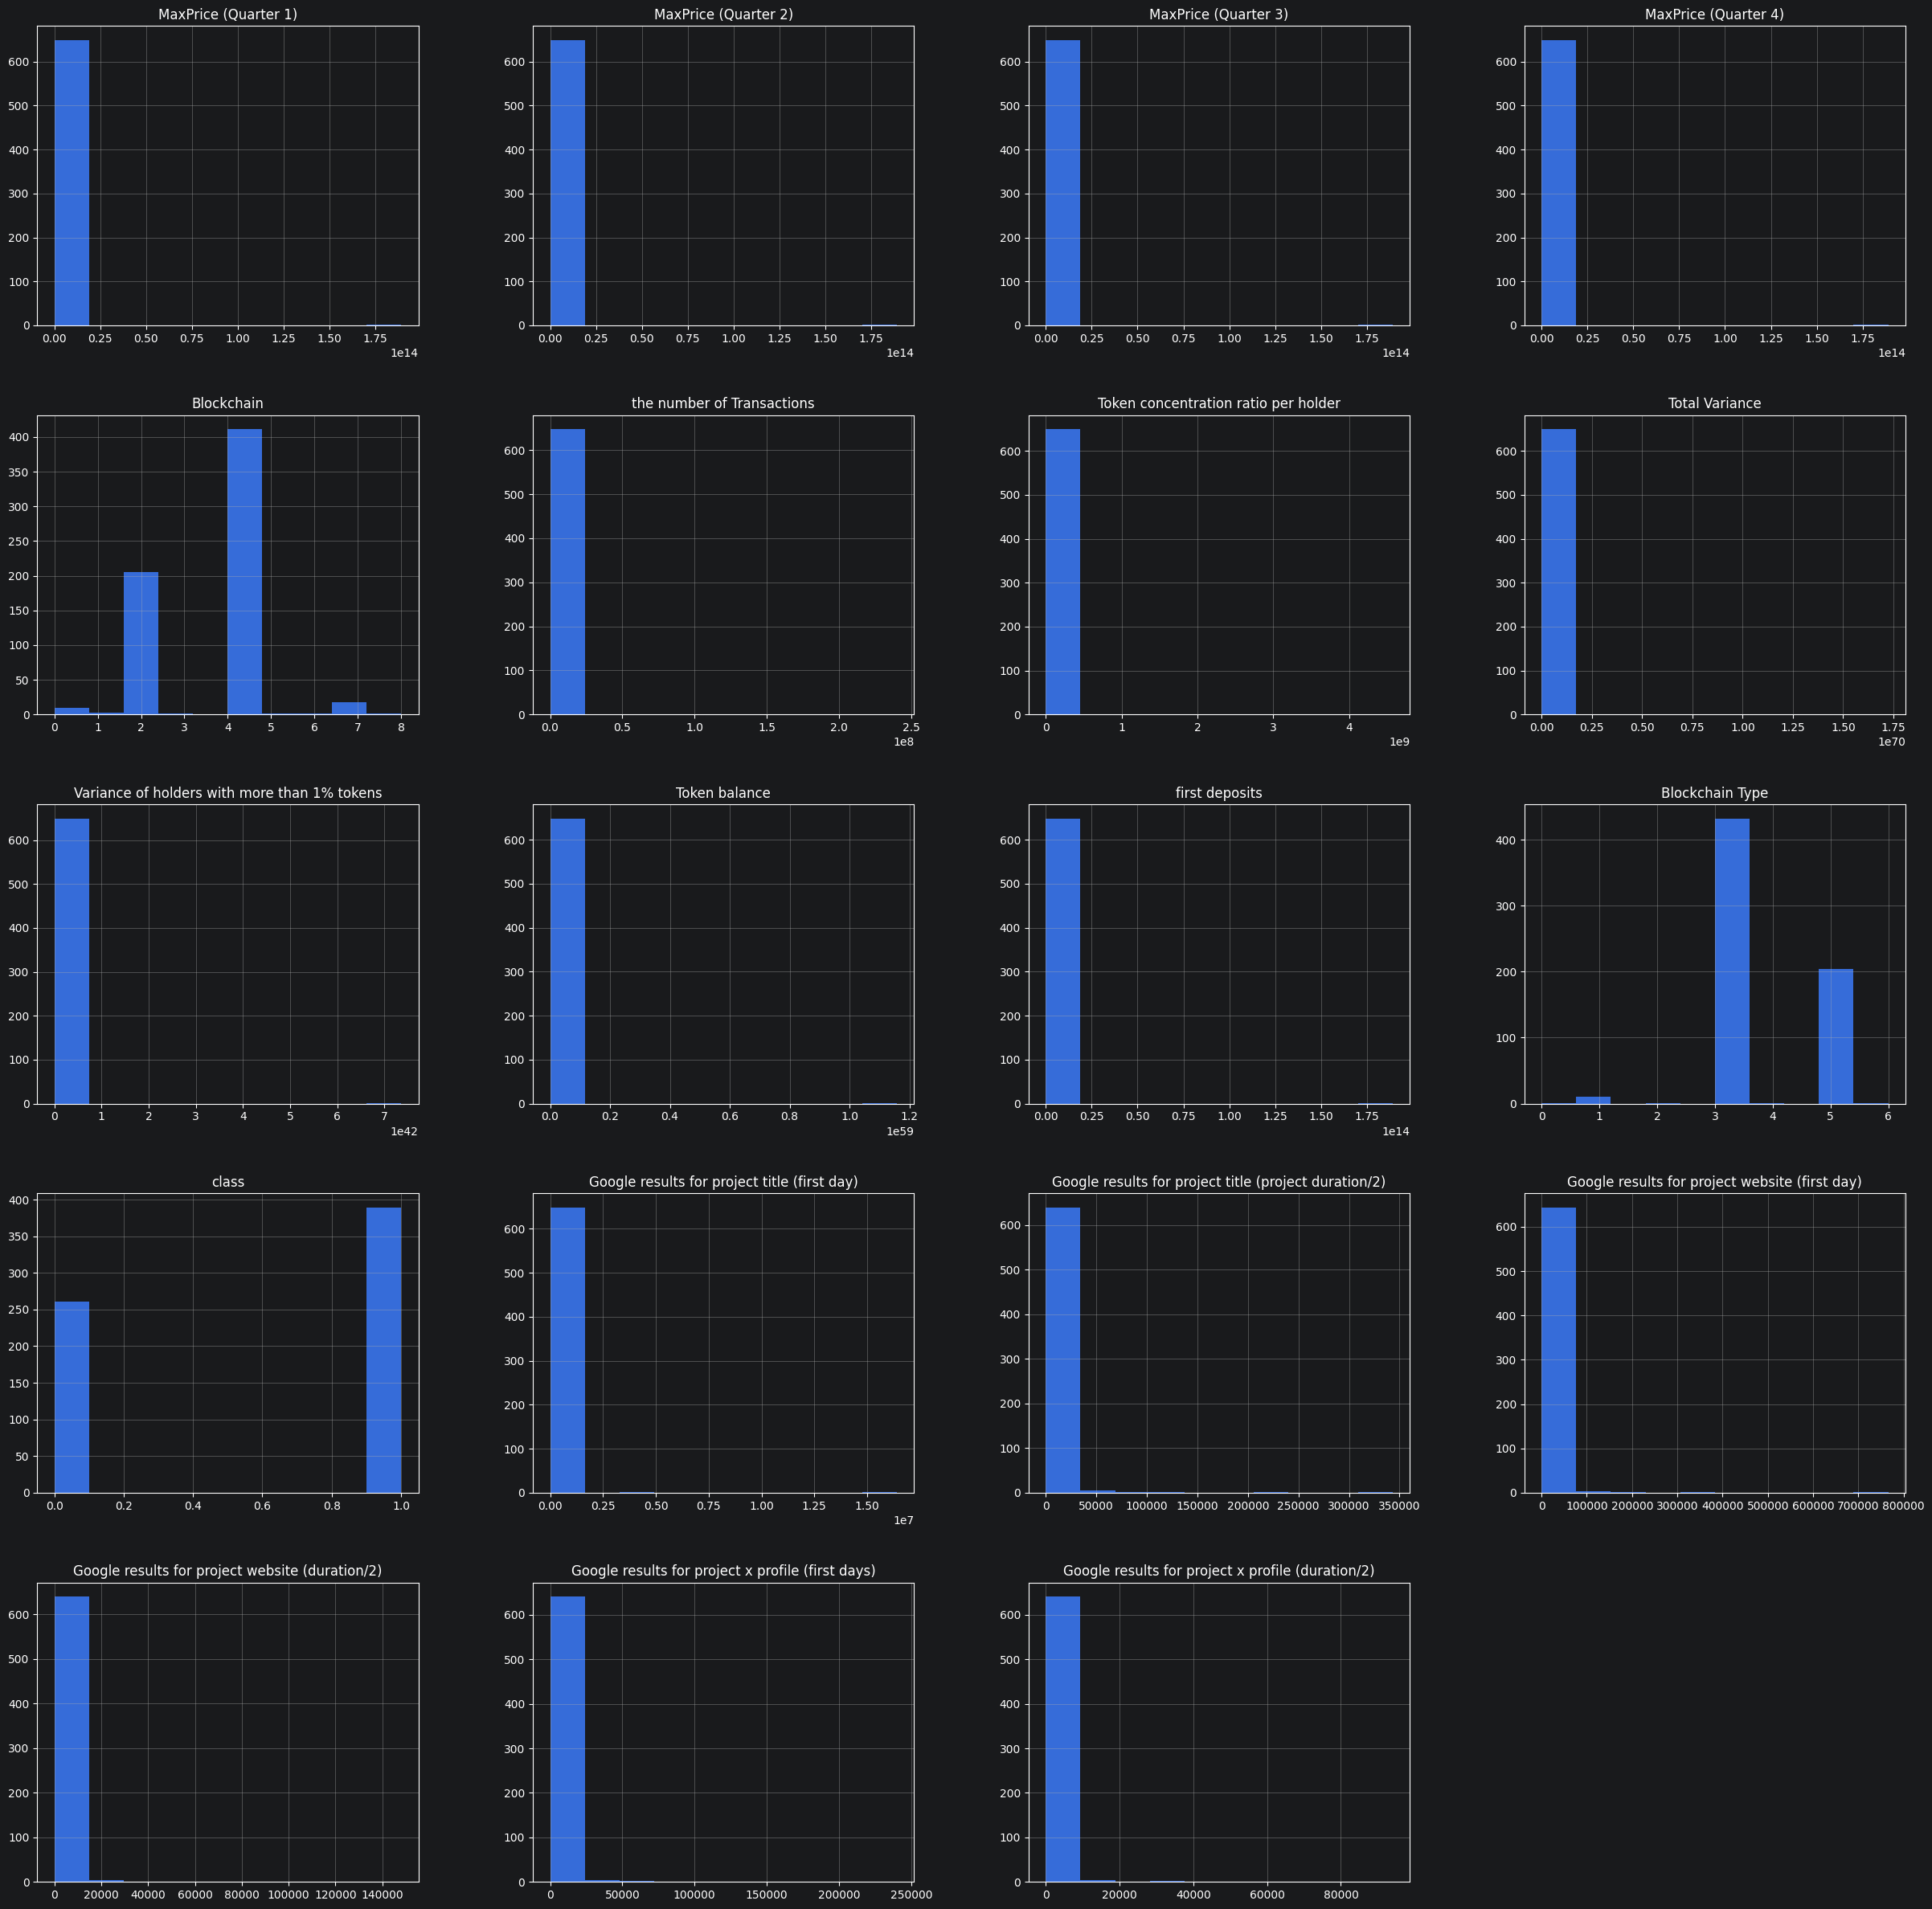

In [23]:
# Histograms

train_set.hist(figsize=[30, 30])
pyplot.show()

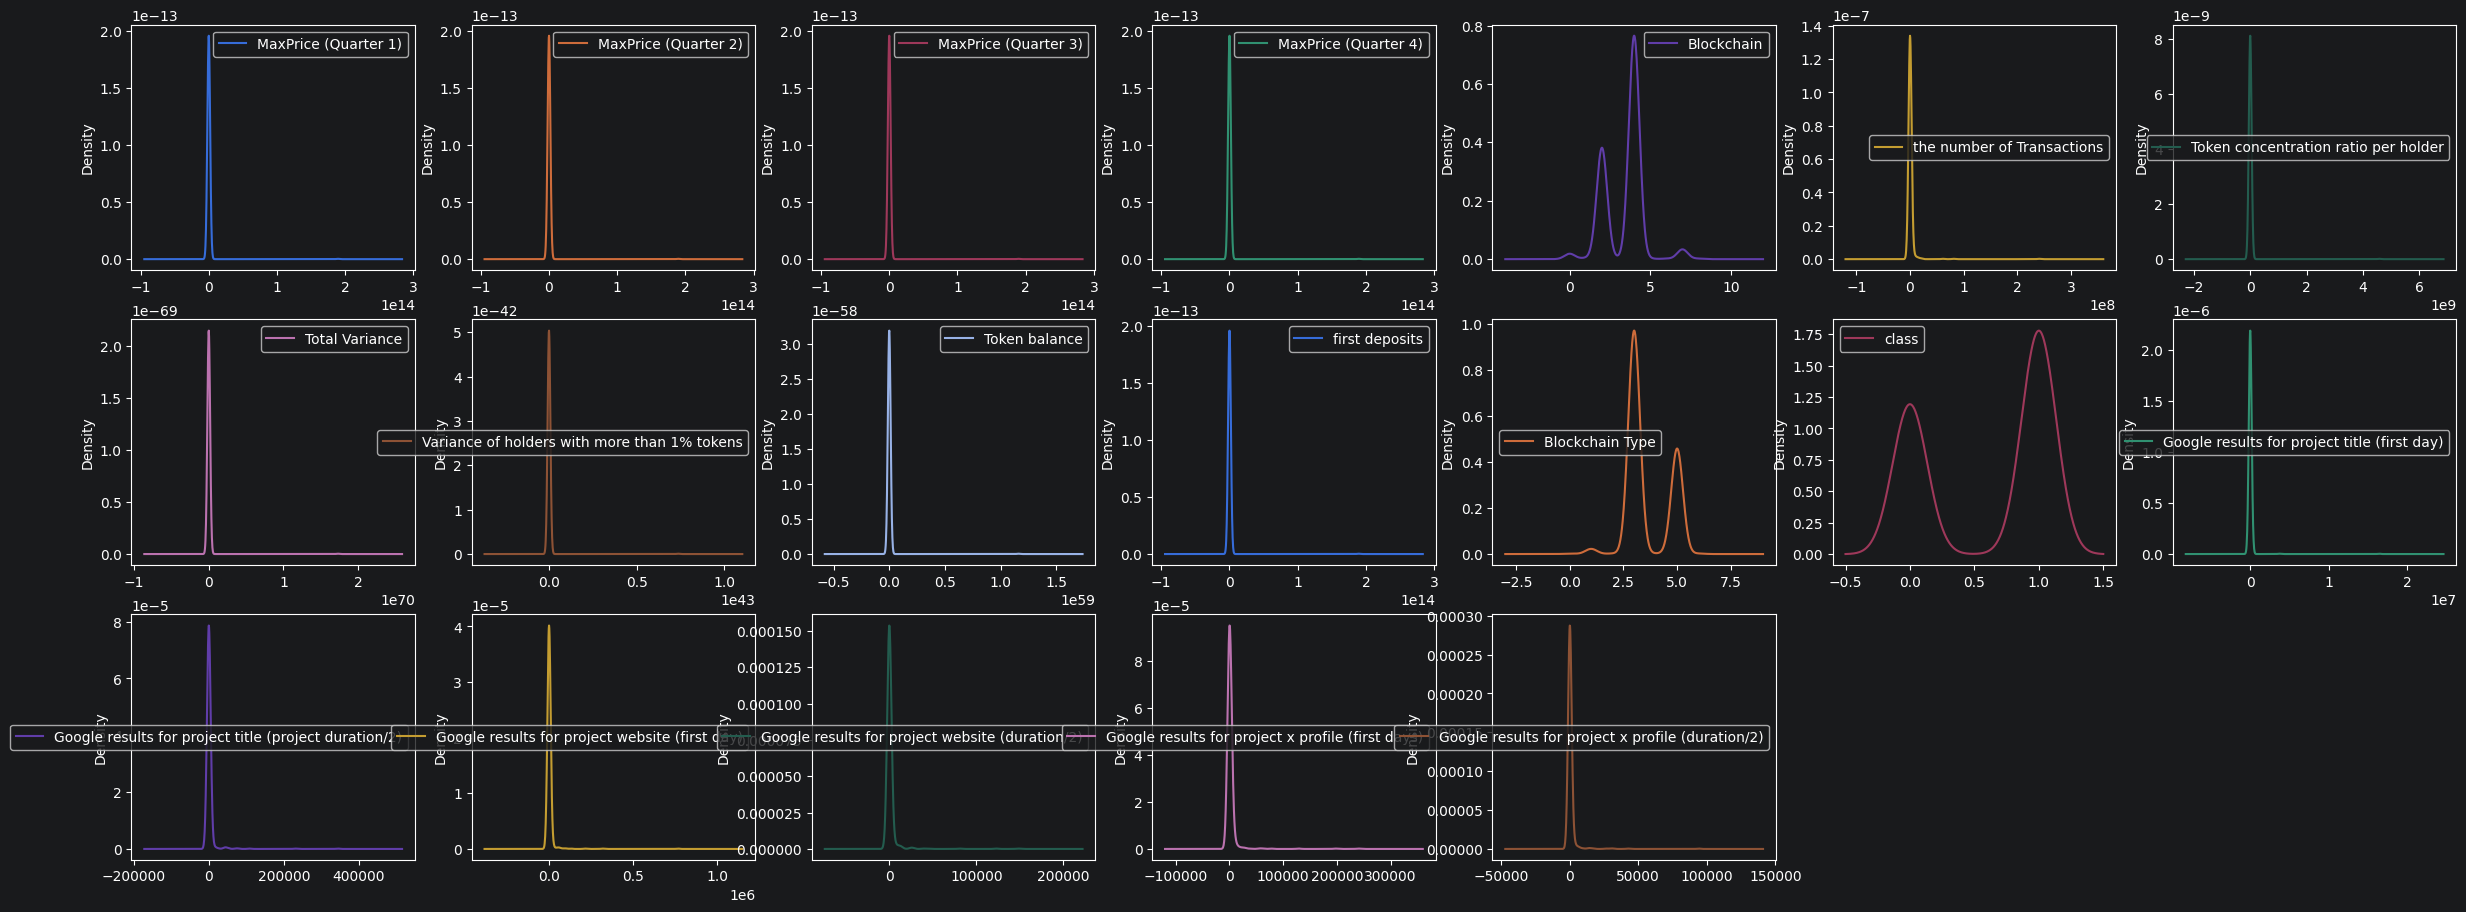

In [24]:
# Density plots

train_set.plot(kind='density', subplots=True, layout=(8,7), sharex=False, sharey=False, figsize=[30, 30])
pyplot.show()

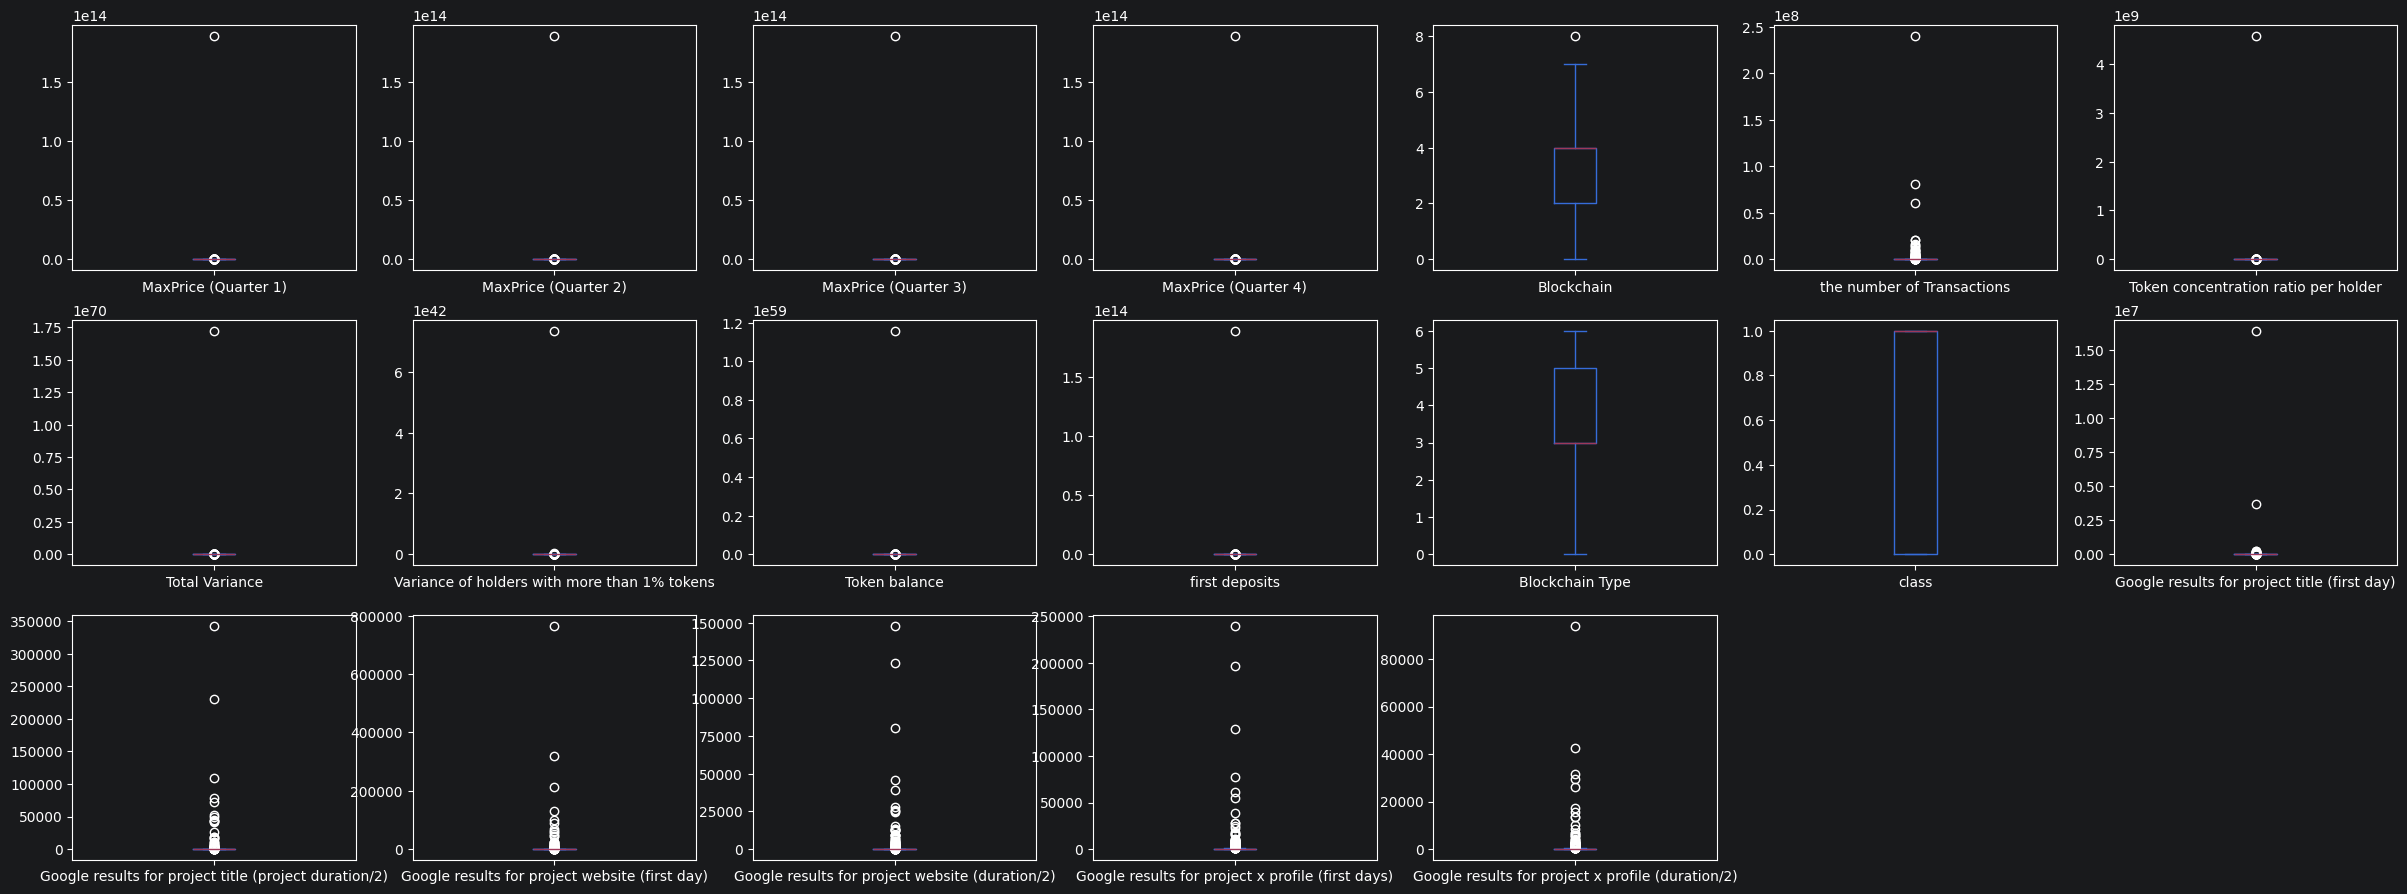

In [25]:
# Box and Whisker Plots

train_set.plot(kind='box', subplots=True, layout=(8,7), sharex=False, sharey=False,figsize=[30, 30])
pyplot.show()

In [27]:
# Search for correlations of features

correlations = train_set.corr(method='pearson')

correlations

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,first deposits,Blockchain Type,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
MaxPrice (Quarter 1),1.000000,0.999998,0.999998,0.999999,-0.045461,-0.004132,-0.001550,-0.001544,-0.001552,-0.001546,0.999999,0.055415,0.032212,-0.002034,-0.004765,-0.004219,-0.005723,-0.005902,-0.005946
MaxPrice (Quarter 2),0.999998,1.000000,1.000000,1.000000,-0.045380,-0.004125,-0.001547,-0.001541,-0.001549,-0.001543,1.000000,0.055316,0.032154,-0.002030,-0.004756,-0.004211,-0.005713,-0.005947,-0.006024
MaxPrice (Quarter 3),0.999998,1.000000,1.000000,1.000000,-0.045380,-0.004125,-0.001547,-0.001541,-0.001549,-0.001543,1.000000,0.055316,0.032154,-0.002030,-0.004756,-0.004211,-0.005713,-0.005947,-0.006024
MaxPrice (Quarter 4),0.999999,1.000000,1.000000,1.000000,-0.045406,-0.004127,-0.001548,-0.001542,-0.001550,-0.001544,1.000000,0.055347,0.032172,-0.002031,-0.004759,-0.004214,-0.005716,-0.005933,-0.005999
Blockchain,-0.045461,-0.045380,-0.045380,-0.045406,1.000000,0.004581,-0.045433,0.019879,0.019698,0.019913,-0.045387,-0.631418,-0.156547,-0.054346,-0.054167,0.020418,0.020498,0.014845,-0.010291
the number of Transactions,-0.004132,-0.004125,-0.004125,-0.004127,0.004581,1.000000,-0.001278,-0.004127,-0.004149,-0.004127,-0.004134,-0.009339,-0.118024,-0.005122,-0.010166,0.005500,0.014004,0.020432,0.013823
Token concentration ratio per holder,-0.001550,-0.001547,-0.001547,-0.001548,-0.045433,-0.001278,1.000000,-0.001547,-0.001555,-0.001549,-0.001550,0.055356,-0.048066,-0.002035,-0.004699,-0.004213,-0.005697,-0.005870,-0.005897
Total Variance,-0.001544,-0.001541,-0.001541,-0.001542,0.019879,-0.004127,-0.001547,1.000000,-0.001549,-0.001543,-0.001544,-0.023533,0.032154,-0.002030,-0.004750,-0.004211,-0.005713,-0.005854,-0.005758
Variance of holders with more than 1% tokens,-0.001552,-0.001549,-0.001549,-0.001550,0.019698,-0.004149,-0.001555,-0.001549,1.000000,-0.001551,-0.001552,-0.023313,0.032325,-0.002041,-0.004777,-0.004070,-0.005051,-0.005957,-0.006031
Token balance,-0.001546,-0.001543,-0.001543,-0.001544,0.019913,-0.004127,-0.001549,-0.001543,-0.001551,1.000000,-0.001547,-0.023576,0.032219,-0.002029,-0.004651,-0.004218,-0.005722,-0.005863,-0.005751


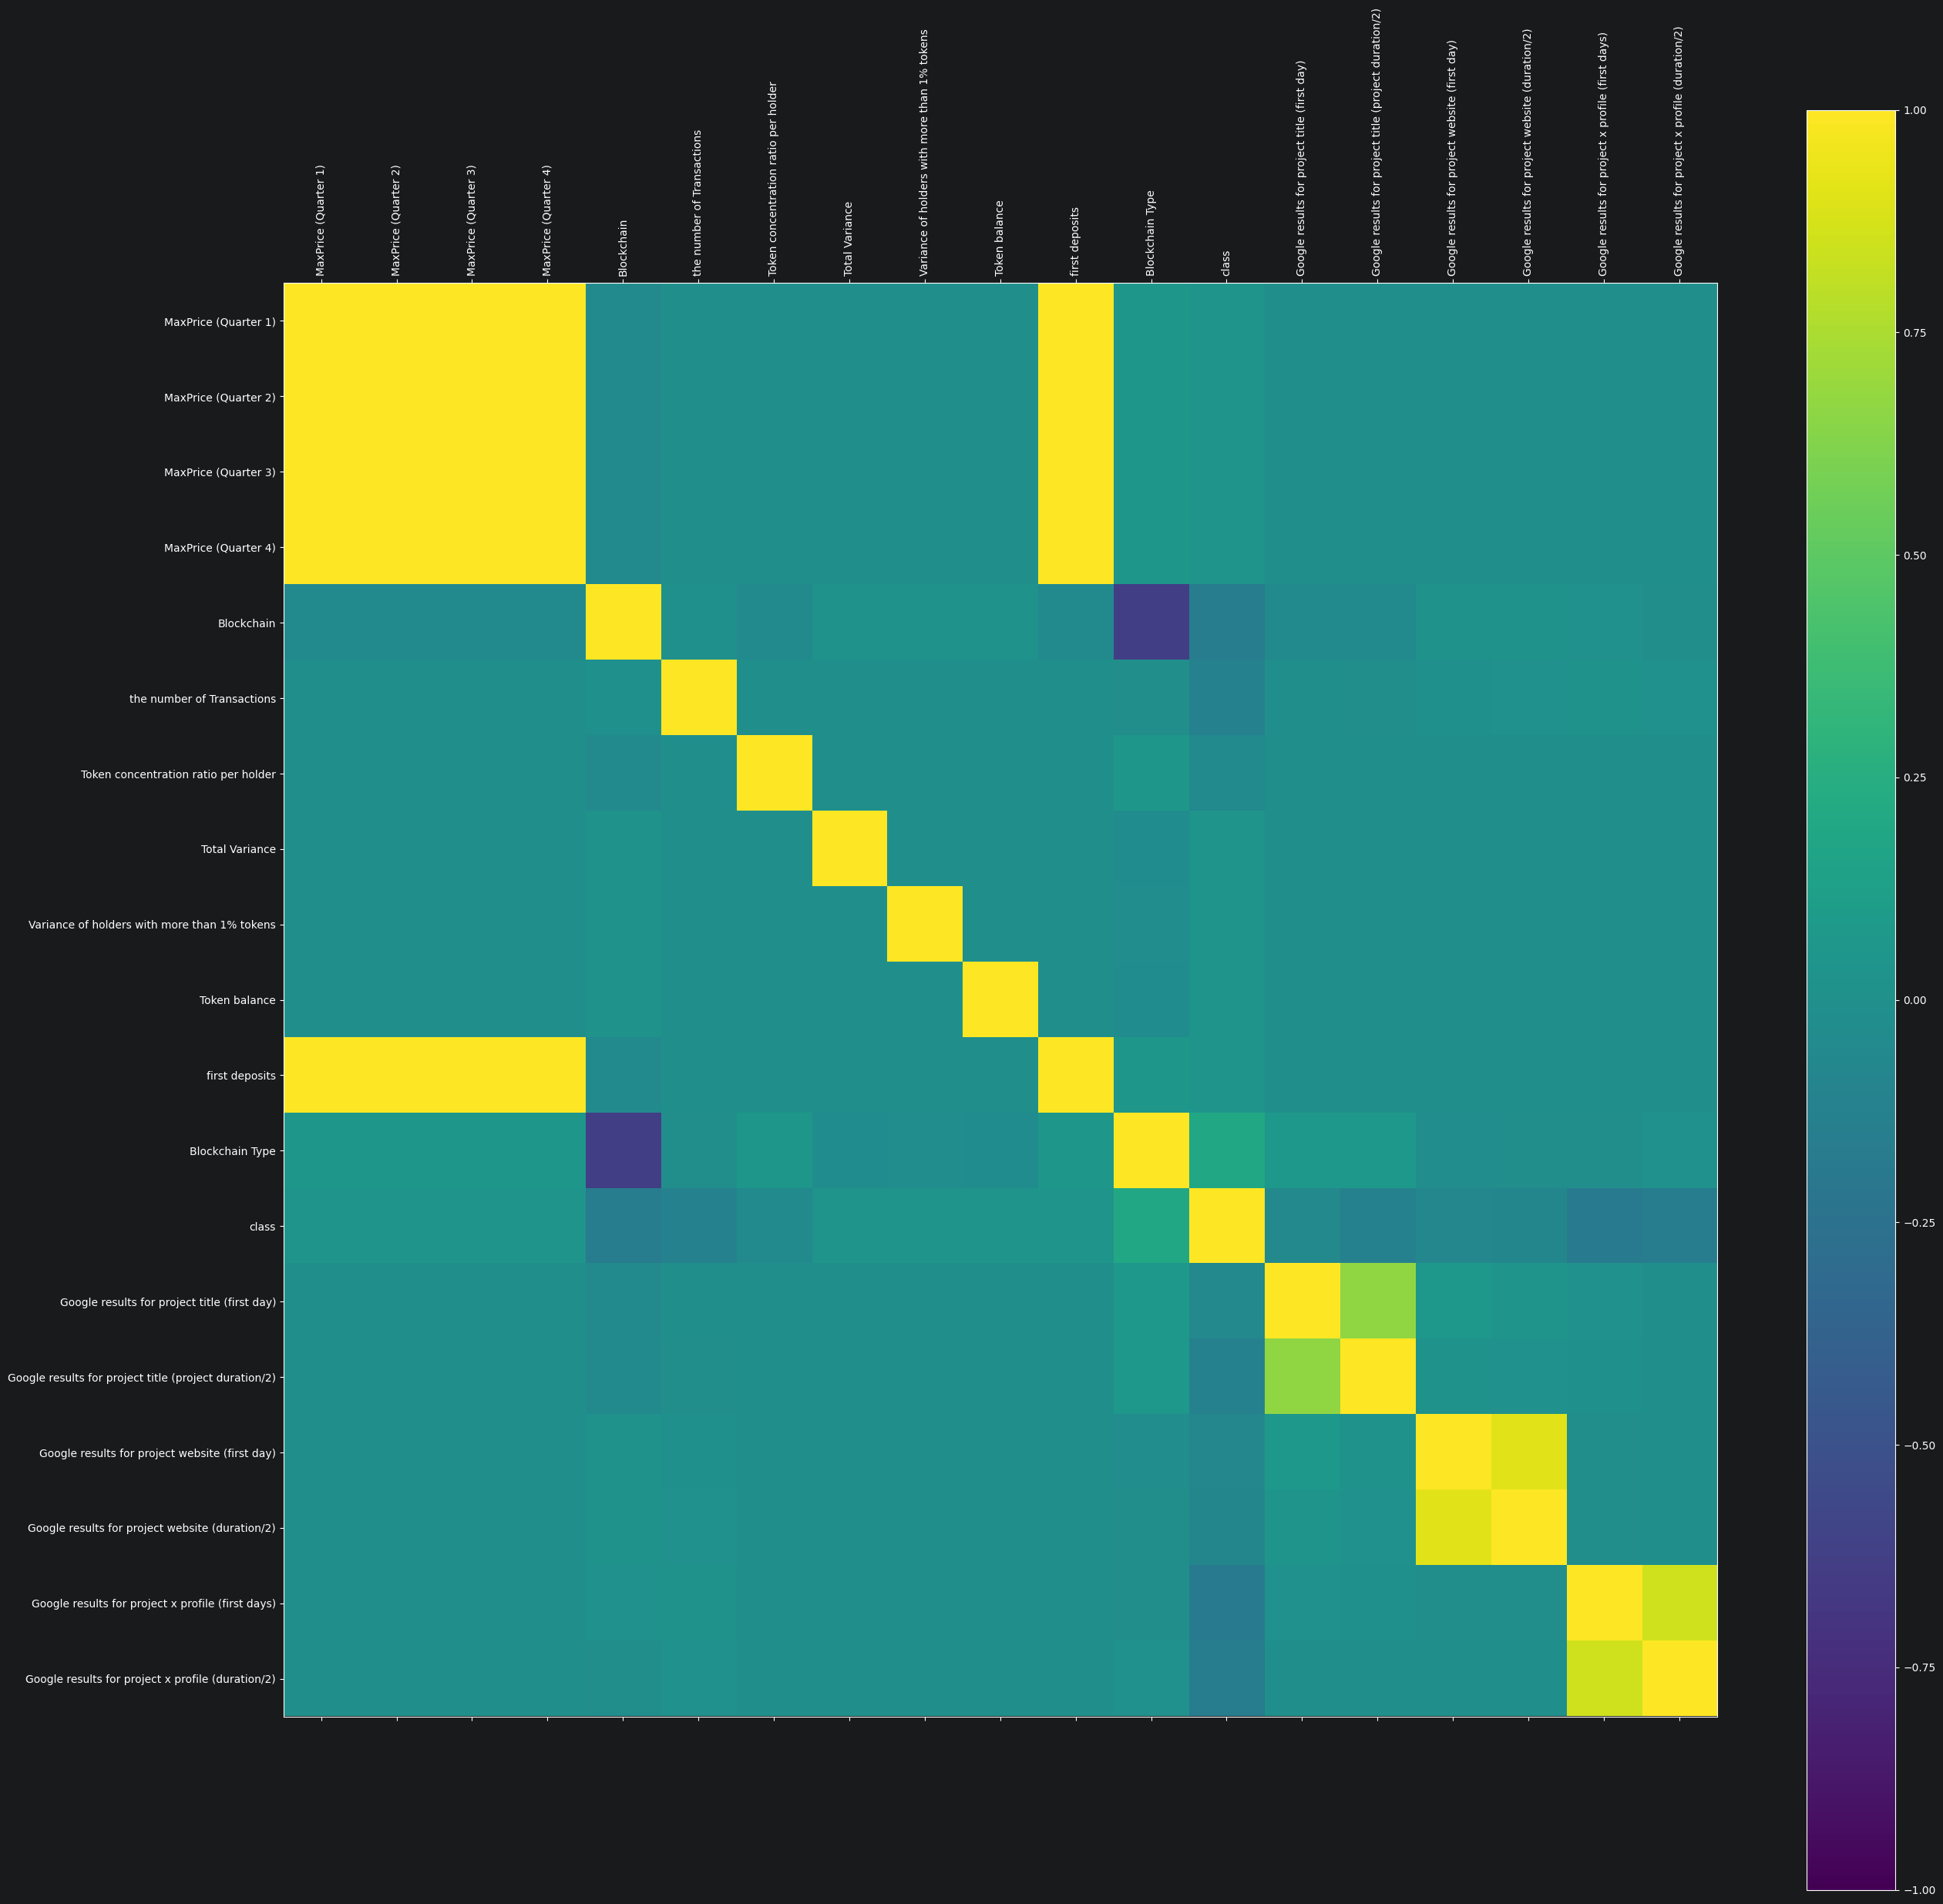

In [28]:
# Correlation Matrix Plot
# TODO: reference to AML tutorial

fig = pyplot.figure(figsize=[30, 30])
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)

ticks = np.arange(0,19,1)

ax.set_xticks(ticks)
ax.set_yticks(ticks)

short_names = list(train_set.columns)

ax.set_xticklabels(short_names)
ax.set_yticklabels(short_names)

pyplot.xticks(rotation=90)     # https://www.geeksforgeeks.org/how-to-rotate-x-axis-tick-label-text-in-matplotlib/?ysclid=lxdkiwmkrh456759424

pyplot.show()

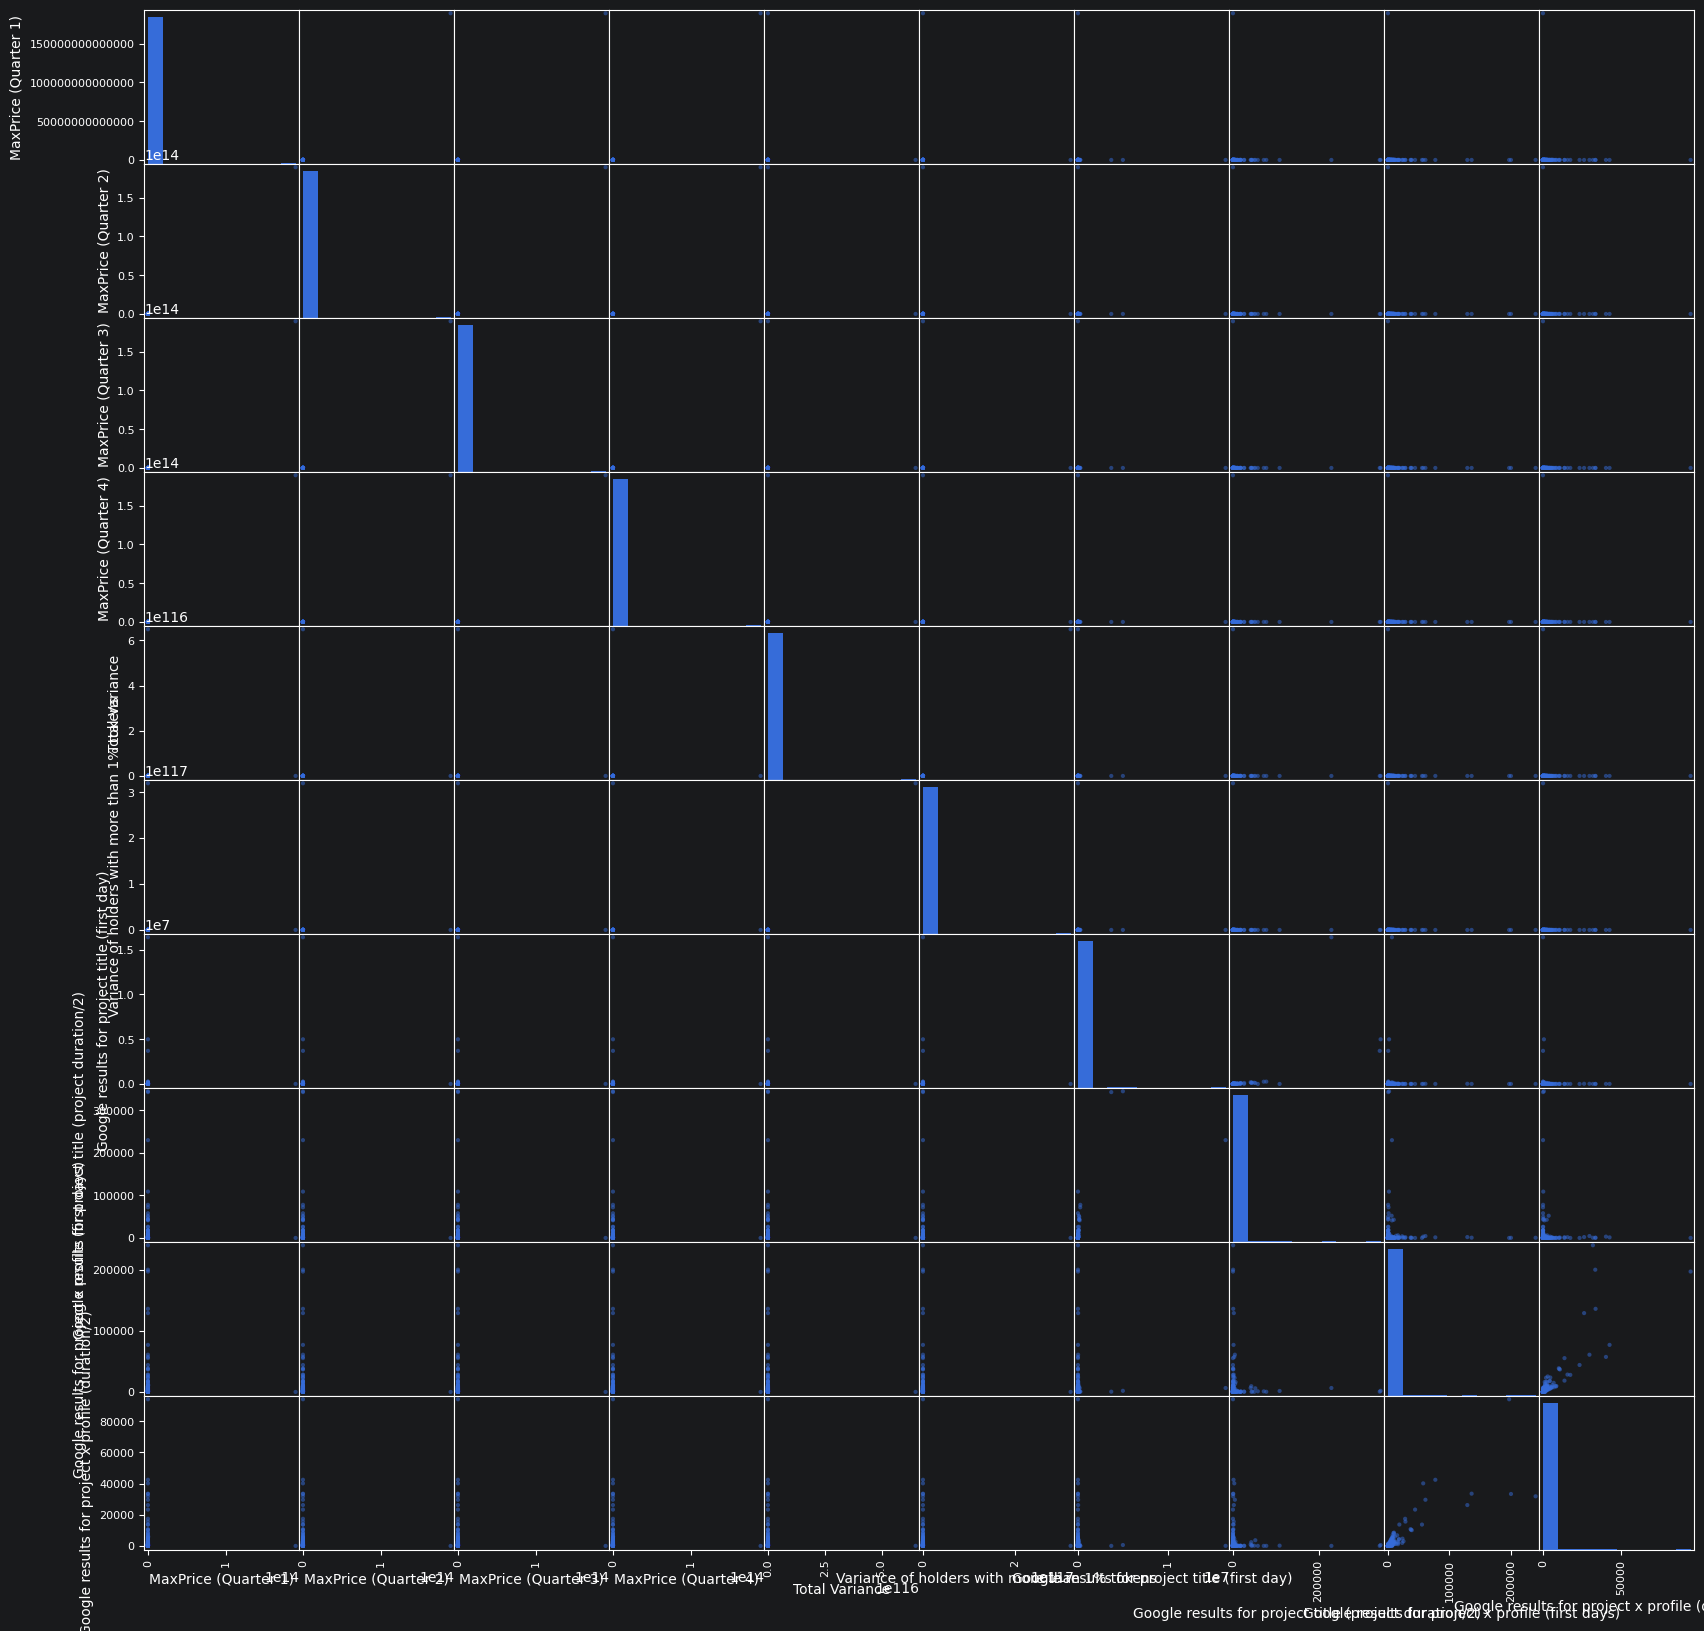

In [29]:
# Scatter plot Matrix
# TODO: make it more readable

pd.plotting.scatter_matrix(data, figsize=[20, 20])

pyplot.show()

## Pre-processing of data

### Based on results of data analysis on raw data

In [ ]:
# TODO: data require preparation and pre-processing (heavy skew, issues with 'first deposit' column (it seems that it is incorrect, duplicating Q1), outliers + a couple of missing values

# TODO: preparation and pre-processing